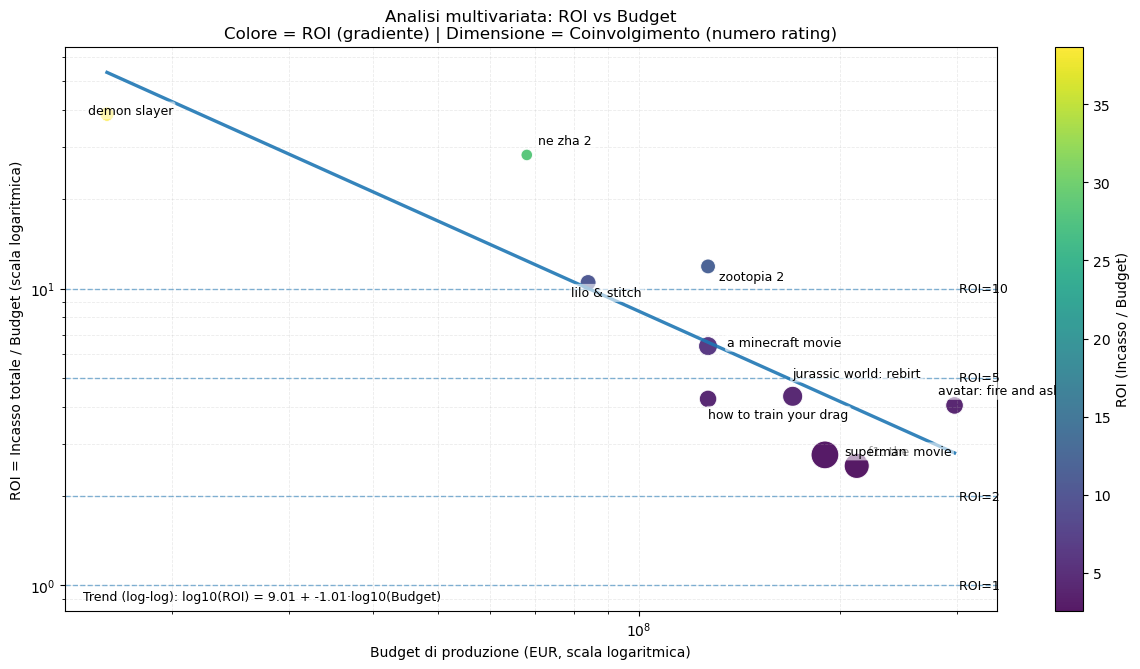

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

def leggi(nomi):
    for n in nomi:
        try:
            t = pd.read_csv(n)
            t.drop(columns=[c for c in t.columns if "Unnamed" in c], inplace=True, errors="ignore")
            t.columns = t.columns.str.strip()
            return t
        except:
            pass
    raise FileNotFoundError(str(nomi))

def norm_film(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

def parse_budget_eur(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["", "-", "nan", "none"]:
        return np.nan
    m = re.search(r"(\d+(?:[.,]\d+)?)", s)
    if not m:
        return np.nan
    num = float(m.group(1).replace(",", "."))
    if "miliard" in s:
        return num * 1e9
    if "milion" in s:
        return num * 1e6
    return num

def parse_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.lower() in ["", "-", "nan", "none"]:
        return np.nan
    s = re.sub(r"[\$,€]", "", s)
    s = s.replace(" ", "").replace(",", "")
    s = re.sub(r"[^0-9\.]", "", s)
    if s == "":
        return np.nan
    return float(s)

def parse_rating(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower().replace("/10", "")
    try:
        return float(s)
    except:
        return np.nan

budget  = leggi(["Budget.csv"])
incassi = leggi(["IncassiTot.csv"])
rating  = leggi(["Rating.csv"])

budget  = budget.rename(columns={"Nome del film": "Movie"})
incassi = incassi.rename(columns={"Nome del film": "Movie"})
rating  = rating.rename(columns={"Nome del film": "Movie"})

for t in [budget, incassi, rating]:
    t["Movie"] = t["Movie"].apply(norm_film)

budget["Budget_EUR"] = budget["Budget (in euro)"].apply(parse_budget_eur)
incassi["Revenue_EUR"] = incassi["Incassi (in euro)"].apply(parse_money)
rating["Rating_Value"] = rating["Rating"].apply(parse_rating)
rating["Rating_Count"] = rating["numero rating"].apply(parse_money)

df = (
    budget[["Movie", "Budget_EUR"]]
    .merge(incassi[["Movie", "Revenue_EUR"]], on="Movie", how="inner")
    .merge(rating[["Movie", "Rating_Value", "Rating_Count"]], on="Movie", how="left")
)

df = df.dropna(subset=["Budget_EUR", "Revenue_EUR"]).copy()
df["ROI"] = df["Revenue_EUR"] / df["Budget_EUR"]

dati = df.dropna(subset=["Budget_EUR", "ROI"]).copy()

x = dati["Budget_EUR"].astype(float).to_numpy()
y = dati["ROI"].astype(float).to_numpy()

if "Rating_Count" in dati.columns and dati["Rating_Count"].notna().any():
    coinvolgimento = dati["Rating_Count"].fillna(dati["Rating_Count"].median()).astype(float).to_numpy()
    cmin, cmax = np.nanmin(coinvolgimento), np.nanmax(coinvolgimento)
    if np.isfinite(cmin) and np.isfinite(cmax) and cmax > cmin:
        dimensioni = 70 + 330 * (coinvolgimento - cmin) / (cmax - cmin)
        titolo_dim = "Coinvolgimento (numero rating)"
    else:
        dimensioni = np.full(len(dati), 160.0)
        titolo_dim = "Dimensione fissa"
else:
    dimensioni = np.full(len(dati), 160.0)
    titolo_dim = "Dimensione fissa"

logx = np.log10(x)
logy = np.log10(y)
pendenza, intercetta = np.polyfit(logx, logy, 1)
x_linea = np.logspace(np.nanmin(logx), np.nanmax(logx), 250)
y_trend = 10 ** (intercetta + pendenza * np.log10(x_linea))

plt.figure(figsize=(12.5, 6.8))
sc = plt.scatter(x, y, s=dimensioni, c=y, alpha=0.9, edgecolors="white", linewidths=0.75)
plt.colorbar(sc, label="ROI (Incasso / Budget)")

plt.xscale("log")
plt.yscale("log")

for k in [1, 2, 5, 10]:
    plt.axhline(k, linestyle="--", linewidth=1, alpha=0.55)
    plt.text(np.nanmax(x), k, f" ROI={k} ", va="center", fontsize=9)

plt.plot(x_linea, y_trend, linewidth=2.4, alpha=0.9)

plt.xlabel("Budget di produzione (EUR, scala logaritmica)")
plt.ylabel("ROI = Incasso totale / Budget (scala logaritmica)")
plt.title("Analisi multivariata: ROI vs Budget\nColore = ROI (gradiente) | Dimensione = " + titolo_dim)

plt.text(0.02, 0.02, f"Trend (log-log): log10(ROI) = {intercetta:.2f} + {pendenza:.2f}·log10(Budget)", transform=plt.gca().transAxes, fontsize=9)

offsets = [
    (8,8),(8,-10),(-12,8),(-12,-10),
    (14,0),(0,14),(-14,0),(0,-14)
]

used_positions = []

logx_s = np.log10(dati["Budget_EUR"].astype(float))
logy_s = np.log10(dati["ROI"].astype(float))

xmin, xmax = logx_s.min(), logx_s.max()
ymin, ymax = logy_s.min(), logy_s.max()

xr = max(xmax - xmin, 1e-9)
yr = max(ymax - ymin, 1e-9)

def troppo_vicino(px, py, lista, dx=0.05, dy=0.05):
    for ux, uy in lista:
        if abs(px-ux) < dx and abs(py-uy) < dy:
            return True
    return False

for i, (_, r) in enumerate(dati.iterrows()):
    px = (np.log10(float(r["Budget_EUR"])) - xmin) / xr
    py = (np.log10(float(r["ROI"])) - ymin) / yr
    if troppo_vicino(px, py, used_positions):
        off = offsets[(i+3) % len(offsets)]
    else:
        off = offsets[i % len(offsets)]
    used_positions.append((px, py))
    plt.annotate(
        str(r["Movie"])[:22],
        (float(r["Budget_EUR"]), float(r["ROI"])),
        textcoords="offset points",
        xytext=off,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, lw=0)
    )

plt.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.25)
plt.tight_layout()
plt.show()
